In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../../data/raw/flight_dataset.csv");

In [3]:
df.head()

,Unnamed: 0,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
df.shape

(14640, 16)

In [8]:
df.columns

Index(['Unnamed: 0', 'tweet_id', 'airline_sentiment',
       'airline_sentiment_confidence', 'negativereason',
       'negativereason_confidence', 'airline', 'airline_sentiment_gold',
       'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord',
       'tweet_created', 'tweet_location', 'user_timezone'],
      dtype='str')

In [9]:
df['airline_sentiment'].head(10)

0     neutral
1    positive
2     neutral
3    negative
4    negative
5    negative
6    positive
7     neutral
8    positive
9    positive
Name: airline_sentiment, dtype: str

In [10]:
df['airline_sentiment'].isnull().sum()

np.int64(0)

In [11]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

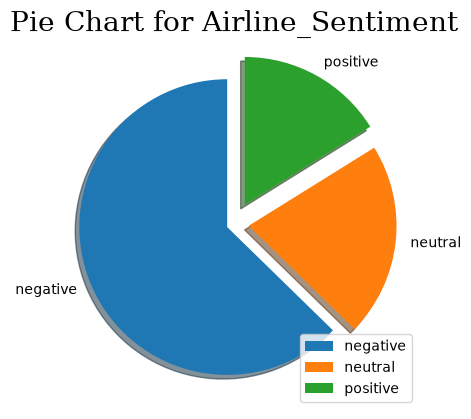

In [12]:
myexplode=[0.05,0.1,0.15]
front_dict={'family':'serif','color':'#000','size':20}
mylabels=['negative','neutral','positive']
plt.pie(df['airline_sentiment'].value_counts(),startangle=90,labels=mylabels,shadow=True,explode=myexplode)
plt.legend()
plt.title('Pie Chart for Airline_Sentiment',fontdict=front_dict)
plt.show() 

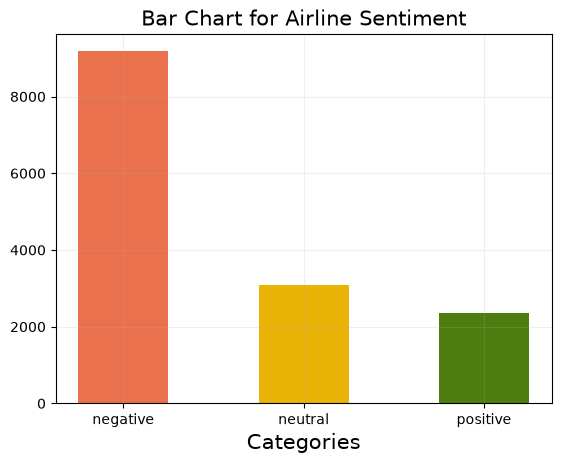

In [13]:
counts=df['airline_sentiment'].value_counts()
col=['#E9724D','#EAB308','#4D7C0F']
front_dict={'color':'#000','size':15}

plt.bar(counts.index,counts.values,width=0.5,color=col)
plt.title('Bar Chart for Airline Sentiment',fontdict=front_dict)
plt.xlabel('Categories',fontdict=front_dict)
plt.grid(alpha=0.2)
plt.show()

In [14]:
duplicates = df[df["text"].duplicated(keep=False)].sort_values("text")
duplicates[["text", "airline_sentiment"]].head(20)


,text,airline_sentiment
12067,.@AmericanAir can you connect me to a person w...,negative
11906,.@AmericanAir can you connect me to a person w...,negative
11902,.@AmericanAir just disappointed with the Fligh...,neutral
12063,.@AmericanAir just disappointed with the Fligh...,neutral
11946,@AmericanAir\n Your response could have made a...,negative
12107,@AmericanAir\n Your response could have made a...,negative
12128,@AmericanAir \nIt's not what happens to us tha...,negative
11967,@AmericanAir \nIt's not what happens to us tha...,negative
13995,@AmericanAir 800 number will not even let you...,negative
12029,@AmericanAir 800 number will not even let you...,negative


In [15]:
duplicate_groups = (
    df.groupby("text")["airline_sentiment"]
      .nunique()
)

duplicate_groups.value_counts()

airline_sentiment
1    14402
2       25
Name: count, dtype: int64

In [16]:
df.drop_duplicates(subset=['text','airline_sentiment'],keep="first",inplace=True)

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
Encoder=LabelEncoder()

In [19]:
df['label']=Encoder.fit_transform(df['airline_sentiment'])

In [20]:
df['label'].value_counts()

label
0    9087
1    3067
2    2298
Name: count, dtype: int64

In [21]:
import joblib
joblib.dump(Encoder,'../../models/tfidf/Encoder_sentiment.pkl')

['../../models/tfidf/Encoder_sentiment.pkl']

In [22]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [23]:
df["clean_text"] = df["text"].apply(clean_text)

In [24]:
df['clean_text']


0                                               what said.
1        plus you've added commercials to the experienc...
2        i didn't today... must mean i need to take ano...
3        it's really aggressive to blast obnoxious "ent...
4                 and it's a really big bad thing about it
                               ...                        
14635    thank you we got on a different flight to chic...
14636    leaving over 20 minutes late flight. no warnin...
14637      please bring american airlines to #blackberry10
14638    you have my money, you change my flight, and d...
14639    we have 8 ppl so we need 2 know how many seats...
Name: clean_text, Length: 14452, dtype: str

In [25]:
from sklearn.model_selection import train_test_split

In [34]:
x=df['clean_text']
y=df['label']

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [39]:
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model=LogisticRegression(max_iter=1000)

In [43]:
model.fit(x_train_tfidf, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [44]:
y_pred = model.predict(x_test_tfidf)

In [45]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1789
           1       0.72      0.49      0.58       626
           2       0.84      0.62      0.71       476

    accuracy                           0.80      2891
   macro avg       0.79      0.69      0.72      2891
weighted avg       0.79      0.80      0.78      2891



In [57]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\airline-complaint-intelligence


In [60]:
from textcleaning import clean_text

In [62]:
joblib.dump(
    model,'../../models/tfidf/logistic_regression.pkl'
)

['../../models/tfidf/logistic_regression.pkl']

In [63]:
joblib.dump(
    tfidf,
    "../../models/tfidf/tfidf_vectorizer.pkl"
)

['../../models/tfidf/tfidf_vectorizer.pkl']